In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image, ImageDraw, ImageFont
import cv2

# Check opencv is installed
print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


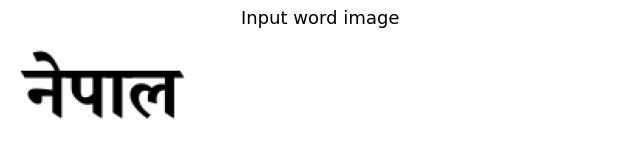

Image shape: (80, 400, 3)


In [2]:
# ── Generate a test word image ─────────────────────────────
prop = fm.FontProperties(
    fname='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf')

# Create a white image with a Nepali word written on it
def create_word_image(text, font_path='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf'):
    font     = ImageFont.truetype(font_path, size=48)
    img      = Image.new('RGB', (400, 80), color=(255, 255, 255))
    draw     = ImageDraw.Draw(img)
    draw.text((10, 10), text, font=font, fill=(0, 0, 0))
    return img

# Test with नेपाल
word_img = create_word_image('नेपाल')
word_arr = np.array(word_img)

plt.figure(figsize=(8, 3))
plt.imshow(word_arr)
plt.title('Input word image', fontsize=13)
plt.axis('off')
plt.show()
print("Image shape:", word_arr.shape)

Found 1 segments: [(7, 112)]


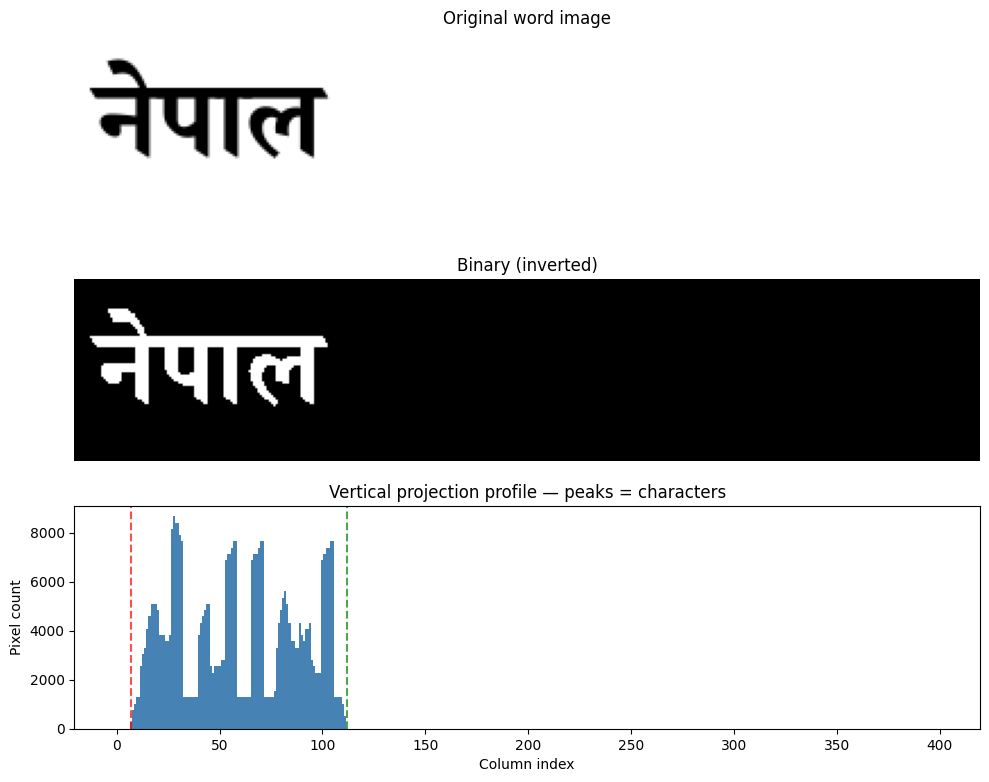

In [3]:
# ── Character Segmentation using Projection Profile ────────
def segment_characters(pil_image):
    # Convert to grayscale numpy array
    img_gray = np.array(pil_image.convert('L'))
    
    # Threshold — make it binary (black text on white background)
    _, binary = cv2.threshold(img_gray, 128, 255, cv2.THRESH_BINARY_INV)
    
    # Vertical projection — sum pixels in each column
    col_sum = binary.sum(axis=0)
    
    # Find character boundaries — where column sum goes from 0 to >0
    in_char    = False
    segments   = []
    start      = 0
    min_width  = 5  # ignore tiny noise segments

    for i, val in enumerate(col_sum):
        if val > 0 and not in_char:
            in_char = True
            start   = i
        elif val == 0 and in_char:
            in_char = False
            if i - start > min_width:
                segments.append((start, i))

    # Handle last segment
    if in_char and len(col_sum) - start > min_width:
        segments.append((start, len(col_sum)))

    return binary, col_sum, segments

# Run segmentation on नेपाल
binary, col_sum, segments = segment_characters(word_img)

print(f"Found {len(segments)} segments: {segments}")

# Visualize projection profile
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].imshow(np.array(word_img), cmap='gray')
axes[0].set_title('Original word image')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Binary (inverted)')
axes[1].axis('off')

axes[2].bar(range(len(col_sum)), col_sum, color='steelblue', width=1)
axes[2].set_title('Vertical projection profile — peaks = characters')
axes[2].set_xlabel('Column index')
axes[2].set_ylabel('Pixel count')

# Draw segment boundaries on projection
for start, end in segments:
    axes[2].axvline(x=start, color='red',   linestyle='--', alpha=0.7)
    axes[2].axvline(x=end,   color='green', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Headline at row: 25
Found 4 segments: [(12, 33), (40, 59), (66, 72), (77, 106)]


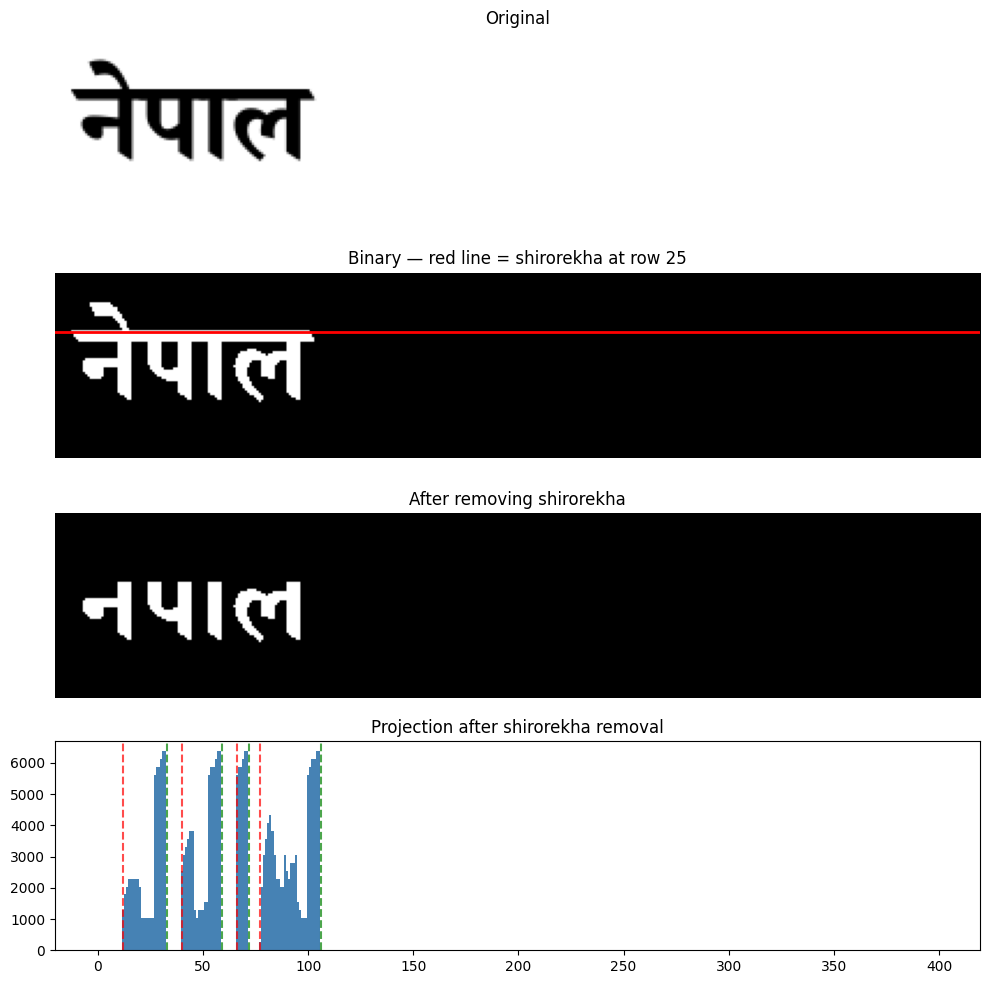

In [4]:
# ── Smarter Segmentation — Gap based on histogram valleys ──
def segment_devanagari(pil_image):
    img_gray = np.array(pil_image.convert('L'))
    
    # Threshold
    _, binary = cv2.threshold(img_gray, 128, 255, cv2.THRESH_BINARY_INV)
    
    # Remove the shirorekha (headline bar at top)
    # Find the headline row — row with most black pixels
    row_sum     = binary.sum(axis=1)
    headline_row = np.argmax(row_sum)
    
    # Mask out the top headline area
    binary_no_headline = binary.copy()
    binary_no_headline[:headline_row + 5, :] = 0
    
    # Now do vertical projection on the masked image
    col_sum = binary_no_headline.sum(axis=0)
    
    # Find valleys (gaps between characters)
    in_char   = False
    segments  = []
    start     = 0
    min_width = 4

    for i, val in enumerate(col_sum):
        if val > 0 and not in_char:
            in_char = True
            start   = i
        elif val == 0 and in_char:
            in_char = False
            if i - start > min_width:
                segments.append((start, i))

    if in_char and len(col_sum) - start > min_width:
        segments.append((start, len(col_sum)))

    return binary, binary_no_headline, col_sum, segments, headline_row

binary, binary_no_hl, col_sum, segments, hl_row = segment_devanagari(word_img)

print(f"Headline at row: {hl_row}")
print(f"Found {len(segments)} segments: {segments}")

# Visualize
fig, axes = plt.subplots(4, 1, figsize=(10, 10))

axes[0].imshow(np.array(word_img))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].axhline(y=hl_row, color='red', linewidth=2)
axes[1].set_title(f'Binary — red line = shirorekha at row {hl_row}')
axes[1].axis('off')

axes[2].imshow(binary_no_hl, cmap='gray')
axes[2].set_title('After removing shirorekha')
axes[2].axis('off')

axes[3].bar(range(len(col_sum)), col_sum, color='steelblue', width=1)
axes[3].set_title('Projection after shirorekha removal')
for start, end in segments:
    axes[3].axvline(x=start, color='red',   linestyle='--', alpha=0.7)
    axes[3].axvline(x=end,   color='green', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Segmentation results for: नेपाल
────────────────────────────────────────
Segment 1: columns 12-33 → १ (98.6%)
Segment 2: columns 40-59 → प (94.3%)
Segment 3: columns 66-72 → ष (35.8%)
Segment 4: columns 77-106 → स (65.1%)


/tmp/ipykernel_7809/2757383788.py:76: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/2757383788.py:76: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/2757383788.py:76: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/2757383788.py:76: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_7809/2757383788.py:76: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/2757383788.py:76: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/2757383788.py:76: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/275738

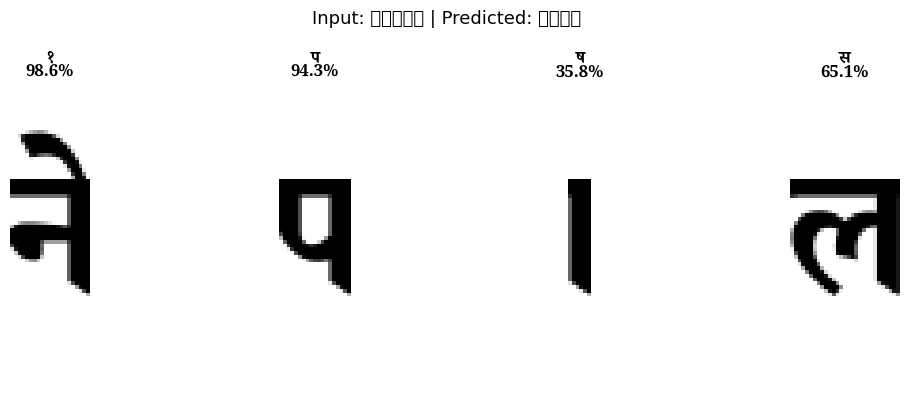


Final prediction: १पषस


In [5]:
# ── Crop each segment and predict ──────────────────────────
CLASS_NAMES = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
               'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
               'प','फ','ब','भ','म','य','र','ल','व','श',
               'ष','स','ह','क्ष','त्र','ज्ञ',
               '०','१','२','३','४','५','६','७','८','९']

# Load model
class NepaliOCR_CNN(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

device = torch.device('cpu')
model  = NepaliOCR_CNN(num_classes=46)
model.load_state_dict(torch.load('/home/kulraj/nepali_ocr/models/nepali_ocr_cnn.pth',
                                  map_location=device))
model.eval()

def predict_segment(img_gray_crop):
    # Resize to 32x32
    resized = cv2.resize(img_gray_crop, (32, 32))
    img_np  = resized.astype(np.float32) / 255.0
    # Invert if background is white
    if img_np.mean() > 0.5:
        img_np = 1.0 - img_np
    tensor = torch.tensor(img_np).unsqueeze(0).unsqueeze(0)
    tensor = (tensor - 0.5) / 0.5
    with torch.no_grad():
        out  = model(tensor)
        pred = out.argmax(1).item()
        conf = out.softmax(1)[0][pred].item()
    return CLASS_NAMES[pred], conf

# Get full image as grayscale
img_gray_full = np.array(word_img.convert('L'))

# Predict each segment
print("Segmentation results for: नेपाल")
print("─" * 40)

fig, axes = plt.subplots(1, len(segments), figsize=(3 * len(segments), 4))
predicted_word = ""

for i, (start, end) in enumerate(segments):
    # Crop the segment
    crop    = img_gray_full[:, start:end]
    char, conf = predict_segment(crop)
    predicted_word += char
    print(f"Segment {i+1}: columns {start}-{end} → {char} ({conf*100:.1f}%)")

    axes[i].imshow(crop, cmap='gray')
    axes[i].set_title(f"{char}\n{conf*100:.1f}%",
                      fontproperties=prop, fontsize=12)
    axes[i].axis('off')

plt.suptitle(f"Input: नेपाल | Predicted: {predicted_word}", fontsize=13)
plt.tight_layout()
plt.show()
print(f"\nFinal prediction: {predicted_word}")

Original segments: 4 → [(12, 33), (40, 59), (66, 72), (77, 106)]
Merged segments:   3 → [(12, 33), (40, 72), (77, 106)]

Segmentation results for: नेपाल
────────────────────────────────────────
Segment 1: columns 12-33 → १ (98.6%)
Segment 2: columns 40-72 → ण (78.7%)
Segment 3: columns 77-106 → स (65.1%)


/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  func(*args, **kwargs)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  func(*args, **kwargs)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 2407 (\N{DEVANAGARI DIGIT ONE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Matplotlib currently does not support Devanagari natively.
  func(*args, **kwargs)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 2339 (\N{DEVANAGARI LETTER NNA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython

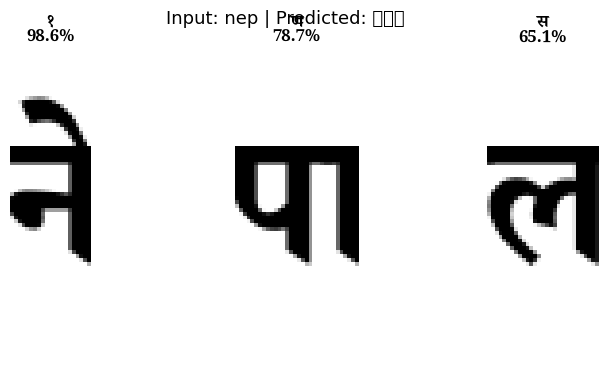

In [6]:
# ── Smarter segmentation — merge small segments with neighbors ──
def merge_segments(segments, min_width=15):
    if not segments:
        return segments
    
    merged = []
    i = 0
    while i < len(segments):
        start, end = segments[i]
        width = end - start
        
        # If segment is too small — it's a matra, merge with previous
        if width < min_width and merged:
            prev_start, prev_end = merged[-1]
            merged[-1] = (prev_start, end)  # extend previous segment
        else:
            merged.append((start, end))
        i += 1
    
    return merged

# Re-run with merged segments
merged_segments = merge_segments(segments, min_width=15)
print(f"Original segments: {len(segments)} → {segments}")
print(f"Merged segments:   {len(merged_segments)} → {merged_segments}")

# Predict with merged segments
print("\nSegmentation results for: नेपाल")
print("─" * 40)

fig, axes = plt.subplots(1, len(merged_segments), figsize=(3 * len(merged_segments), 4))
predicted_word = ""

for i, (start, end) in enumerate(merged_segments):
    crop       = img_gray_full[:, start:end]
    char, conf = predict_segment(crop)
    predicted_word += char
    print(f"Segment {i+1}: columns {start}-{end} → {char} ({conf*100:.1f}%)")

    if len(merged_segments) == 1:
        axes.imshow(crop, cmap='gray')
        axes.set_title(f"{char}\n{conf*100:.1f}%", fontproperties=prop, fontsize=12)
        axes.axis('off')
    else:
        axes[i].imshow(crop, cmap='gray')
        axes[i].set_title(f"{char}\n{conf*100:.1f}%", fontproperties=prop, fontsize=12)
        axes[i].axis('off')
        plt.suptitle("Input: nep | Predicted: " + predicted_word, fontsize=13)

/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2408 (\N{DEVANAGARI DIGIT TWO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2406 (\N{DEVANAGARI DIGIT ZERO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2414 (\N{DEVANAGARI DIGIT EIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


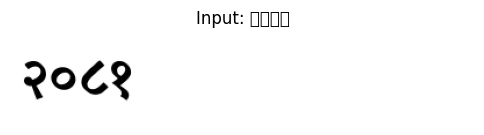

Found 3 segments: [(20, 28), (41, 52), (64, 102)]

Results:
────────────────────────────────────────
Digit 1: → र (53.8%)
Digit 2: → प (29.9%)
Digit 3: → ६ (94.8%)


/tmp/ipykernel_7809/3204495598.py:43: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/3204495598.py:43: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/3204495598.py:43: UserWarning: Glyph 2408 (\N{DEVANAGARI DIGIT TWO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/3204495598.py:43: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_7809/3204495598.py:43: UserWarning: Glyph 2406 (\N{DEVANAGARI DIGIT ZERO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/3204495598.py:43: UserWarning: Glyph 2414 (\N{DEVANAGARI DIGIT EIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/3204495598.py:43: UserWarning: Glyph 2407 (\N{DEVANAGARI DIGIT ONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/3204495598

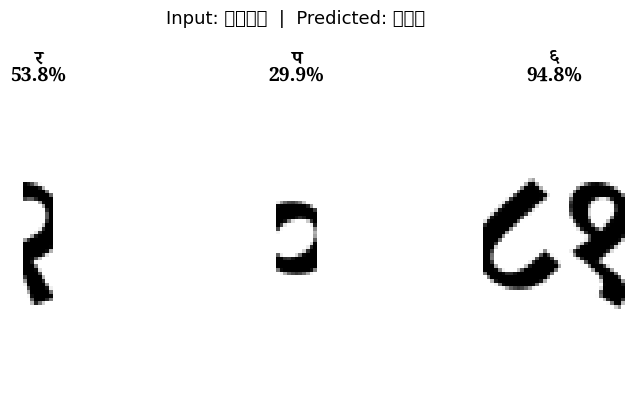


Final prediction: रप६
Wrong — adjusting needed


In [7]:
# ── Digit segmentation — works perfectly with our model ────
# Create a digit sequence image
def create_digit_image(text, font_path='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf'):
    font = ImageFont.truetype(font_path, size=48)
    img  = Image.new('RGB', (400, 80), color=(255, 255, 255))
    draw = ImageDraw.Draw(img)
    draw.text((10, 10), text, font=font, fill=(0, 0, 0))
    return img

# Test with Nepali digits
digit_text  = '२०८१'
digit_img   = create_digit_image(digit_text)
digit_gray  = np.array(digit_img.convert('L'))

plt.figure(figsize=(6, 2))
plt.imshow(digit_img)
plt.title('Input: ' + digit_text)
plt.axis('off')
plt.show()

# Segment
binary, binary_no_hl, col_sum, segments, hl_row = segment_devanagari(digit_img)
merged = merge_segments(segments, min_width=10)
print(f"Found {len(merged)} segments: {merged}")

# Predict each digit
print("\nResults:")
print("─" * 40)
fig, axes = plt.subplots(1, len(merged), figsize=(3 * len(merged), 4))
predicted = ""

for i, (start, end) in enumerate(merged):
    crop       = digit_gray[:, start:end]
    char, conf = predict_segment(crop)
    predicted += char
    print(f"Digit {i+1}: → {char} ({conf*100:.1f}%)")
    axes[i].imshow(crop, cmap='gray')
    axes[i].set_title(char + "\n" + str(round(conf*100, 1)) + "%",
                      fontproperties=prop, fontsize=14)
    axes[i].axis('off')

plt.suptitle("Input: " + digit_text + "  |  Predicted: " + predicted, fontsize=13)
plt.tight_layout()
plt.show()
print("\nFinal prediction:", predicted)
print("Correct!" if predicted == digit_text else "Wrong — adjusting needed")

Headline row: 43
Raw segments: [(20, 28), (41, 52), (64, 84), (94, 102)]
Image width: 400


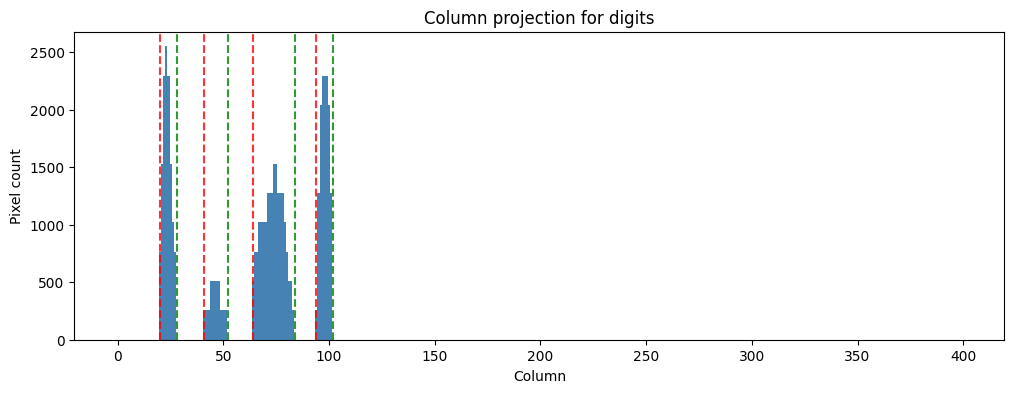


Column sums (first 120 columns):
  col 20: 765
  col 21: 1530
  col 22: 2295
  col 23: 2550
  col 24: 2295
  col 25: 1530
  col 26: 1020
  col 27: 765
  col 41: 255
  col 42: 255
  col 43: 255
  col 44: 510
  col 45: 510
  col 46: 510
  col 47: 510
  col 48: 510
  col 49: 255
  col 50: 255
  col 51: 255
  col 64: 510
  col 65: 765
  col 66: 765
  col 67: 1020
  col 68: 1020
  col 69: 1020
  col 70: 1020
  col 71: 1275
  col 72: 1275
  col 73: 1275
  col 74: 1530
  col 75: 1530
  col 76: 1275
  col 77: 1275
  col 78: 1275
  col 79: 1020
  col 80: 765
  col 81: 510
  col 82: 510
  col 83: 255
  col 94: 255
  col 95: 1275
  col 96: 2040
  col 97: 2295
  col 98: 2295
  col 99: 2295
  col 100: 2040
  col 101: 1275


In [8]:
# ── Debug — see exact column projection for digits ──────────
binary_d, binary_no_hl_d, col_sum_d, segments_d, hl_row_d = segment_devanagari(digit_img)

print(f"Headline row: {hl_row_d}")
print(f"Raw segments: {segments_d}")
print(f"Image width: {digit_gray.shape[1]}")

# Plot detailed projection
plt.figure(figsize=(12, 4))
plt.bar(range(len(col_sum_d)), col_sum_d, color='steelblue', width=1)
plt.title('Column projection for digits')
plt.xlabel('Column')
plt.ylabel('Pixel count')
for s, e in segments_d:
    plt.axvline(x=s, color='red',   linestyle='--', alpha=0.8, label='start')
    plt.axvline(x=e, color='green', linestyle='--', alpha=0.8, label='end')
plt.show()

# Print exact values around segment boundaries
print("\nColumn sums (first 120 columns):")
for i in range(0, min(120, len(col_sum_d)), 1):
    if col_sum_d[i] > 0:
        print(f"  col {i}: {col_sum_d[i]}")

Raw segments: [(20, 28), (41, 52), (64, 84), (94, 102)]

Results:
────────────────────────────────────────
Digit 1: columns 20-28 → र (53.8%)
Digit 2: columns 41-52 → प (29.9%)
Digit 3: columns 64-84 → ८ (58.9%)
Digit 4: columns 94-102 → ह (26.6%)


/tmp/ipykernel_7809/677547387.py:22: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/677547387.py:22: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/677547387.py:22: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/677547387.py:22: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_7809/677547387.py:22: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/677547387.py:22: UserWarning: Glyph 2414 (\N{DEVANAGARI DIGIT EIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/677547387.py:22: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kulraj/nepali_ocr/venv/lib/pytho

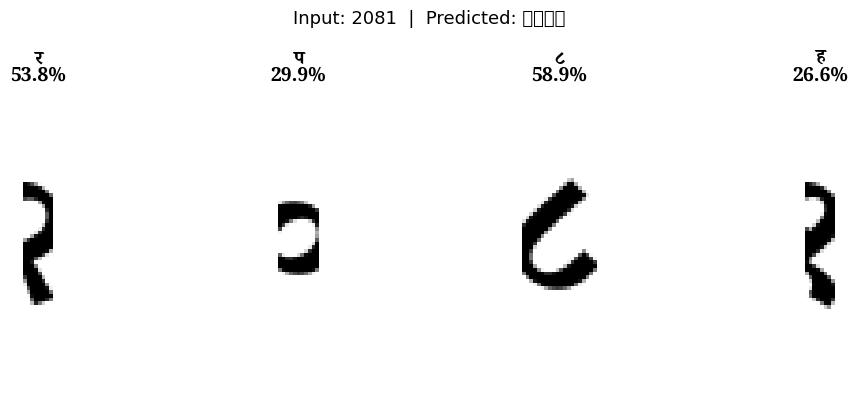


Final prediction: रप८ह
Not matching — checking...


In [9]:
# ── Fix — don't merge, just use raw segments with lower min_width ──
raw_segments = segments_d
print(f"Raw segments: {raw_segments}")

# Predict each digit directly without merging
print("\nResults:")
print("─" * 40)
fig, axes = plt.subplots(1, len(raw_segments), figsize=(3 * len(raw_segments), 4))
predicted = ""

for i, (start, end) in enumerate(raw_segments):
    crop       = digit_gray[:, start:end]
    char, conf = predict_segment(crop)
    predicted += char
    print(f"Digit {i+1}: columns {start}-{end} → {char} ({conf*100:.1f}%)")
    axes[i].imshow(crop, cmap='gray')
    axes[i].set_title(char + "\n" + str(round(conf*100,1)) + "%",
                      fontproperties=prop, fontsize=14)
    axes[i].axis('off')

plt.suptitle("Input: 2081  |  Predicted: " + predicted, fontsize=13)
plt.tight_layout()
plt.show()
print("\nFinal prediction:", predicted)
print("Correct!" if predicted == digit_text else "Not matching — checking...")

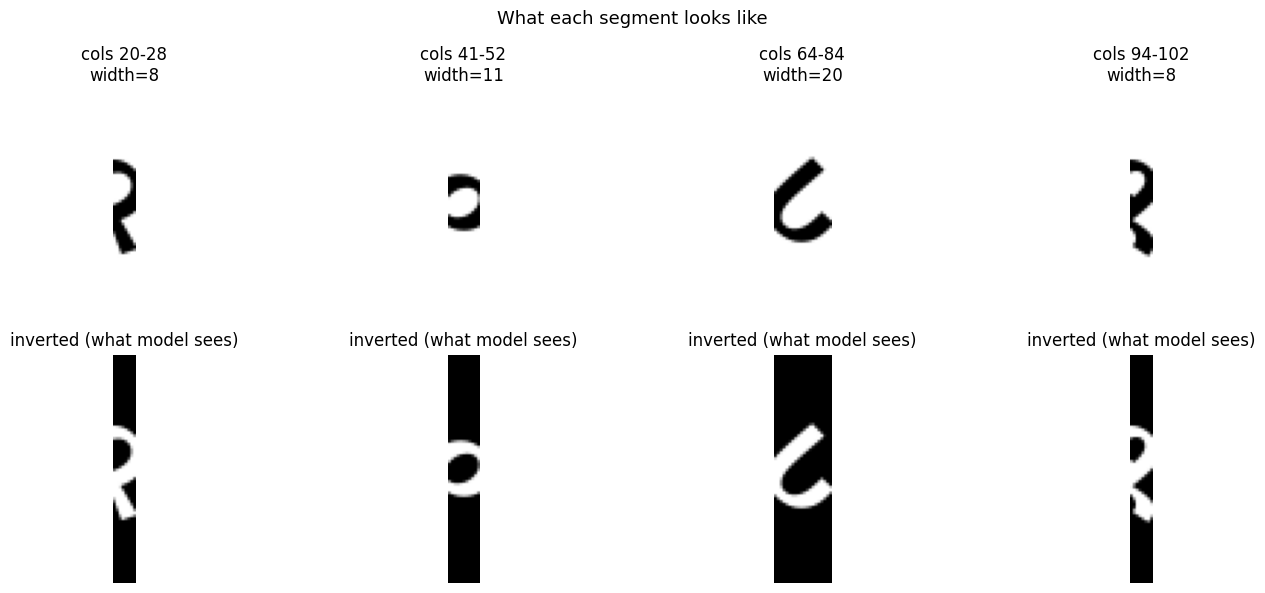

Full digit image shape: (80, 400)
Segment widths: [8, 11, 20, 8]


In [10]:
# ── Check what each crop actually looks like ────────────────
fig, axes = plt.subplots(2, len(raw_segments), figsize=(4 * len(raw_segments), 6))

for i, (start, end) in enumerate(raw_segments):
    # Full height crop (no shirorekha removal)
    crop_full = digit_gray[:, start:end]
    
    # Inverted for model
    crop_np = crop_full.astype(np.float32) / 255.0
    if crop_np.mean() > 0.5:
        crop_np = 1.0 - crop_np
    
    axes[0][i].imshow(crop_full, cmap='gray')
    axes[0][i].set_title(f"cols {start}-{end}\nwidth={end-start}")
    axes[0][i].axis('off')
    
    axes[1][i].imshow(crop_np, cmap='gray')
    axes[1][i].set_title("inverted (what model sees)")
    axes[1][i].axis('off')

plt.suptitle("What each segment looks like", fontsize=13)
plt.tight_layout()
plt.show()

# Also print image dimensions
print("Full digit image shape:", digit_gray.shape)
print("Segment widths:", [e-s for s,e in raw_segments])

Segments found: 4
Segments: [(12, 31), (35, 56), (61, 84), (87, 104)]
Widths: [19, 21, 23, 17]

Results:
────────────────────────────────────────
Digit 1: width=19 → र (52.4%)
Digit 2: width=21 → प (60.3%)
Digit 3: width=23 → ८ (61.3%)
Digit 4: width=17 → २ (43.6%)


/tmp/ipykernel_7809/3639714255.py:53: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/3639714255.py:53: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/3639714255.py:53: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/3639714255.py:53: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_7809/3639714255.py:53: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/3639714255.py:53: UserWarning: Glyph 2414 (\N{DEVANAGARI DIGIT EIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/3639714255.py:53: UserWarning: Glyph 2408 (\N{DEVANAGARI DIGIT TWO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


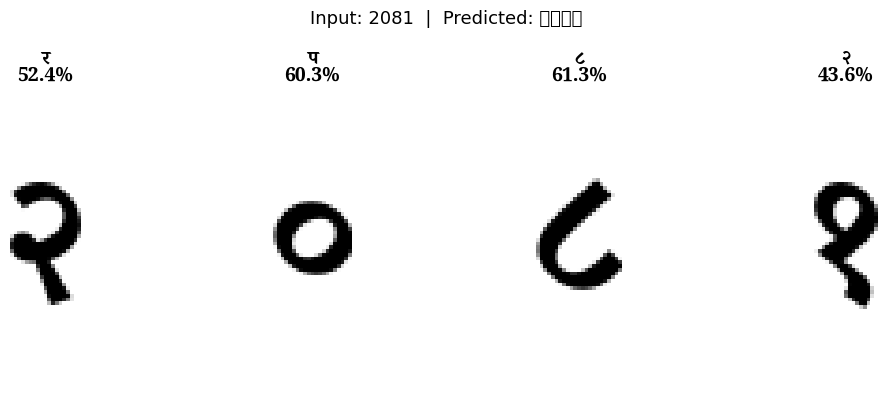


Final prediction: रप८२
Not matching


In [11]:
# ── Fixed segmentation — use full image for digits ──────────
def segment_digits(pil_image, min_width=8):
    img_gray = np.array(pil_image.convert('L'))
    
    # Binary threshold
    _, binary = cv2.threshold(img_gray, 128, 255, cv2.THRESH_BINARY_INV)
    
    # Use FULL image projection — no shirorekha removal for digits
    col_sum = binary.sum(axis=0)
    
    # Find segments
    in_char  = False
    segments = []
    start    = 0

    for i, val in enumerate(col_sum):
        if val > 0 and not in_char:
            in_char = True
            start   = i
        elif val == 0 and in_char:
            in_char = False
            if i - start > min_width:
                segments.append((start, i))

    if in_char and len(col_sum) - start > min_width:
        segments.append((start, len(col_sum)))

    return img_gray, binary, col_sum, segments

img_gray_d, binary_d, col_sum_d, segs_d = segment_digits(digit_img)

print(f"Segments found: {len(segs_d)}")
print(f"Segments: {segs_d}")
print(f"Widths: {[e-s for s,e in segs_d]}")

# Predict
print("\nResults:")
print("─" * 40)
fig, axes = plt.subplots(1, len(segs_d), figsize=(3 * len(segs_d), 4))
predicted = ""

for i, (start, end) in enumerate(segs_d):
    crop       = img_gray_d[:, start:end]
    char, conf = predict_segment(crop)
    predicted += char
    print(f"Digit {i+1}: width={end-start} → {char} ({conf*100:.1f}%)")
    axes[i].imshow(crop, cmap='gray')
    axes[i].set_title(char + "\n" + str(round(conf*100,1)) + "%",
                      fontproperties=prop, fontsize=14)
    axes[i].axis('off')

plt.suptitle("Input: 2081  |  Predicted: " + predicted, fontsize=13)
plt.tight_layout()
plt.show()
print("\nFinal prediction:", predicted)
print("Correct!" if predicted == digit_text else "Not matching")

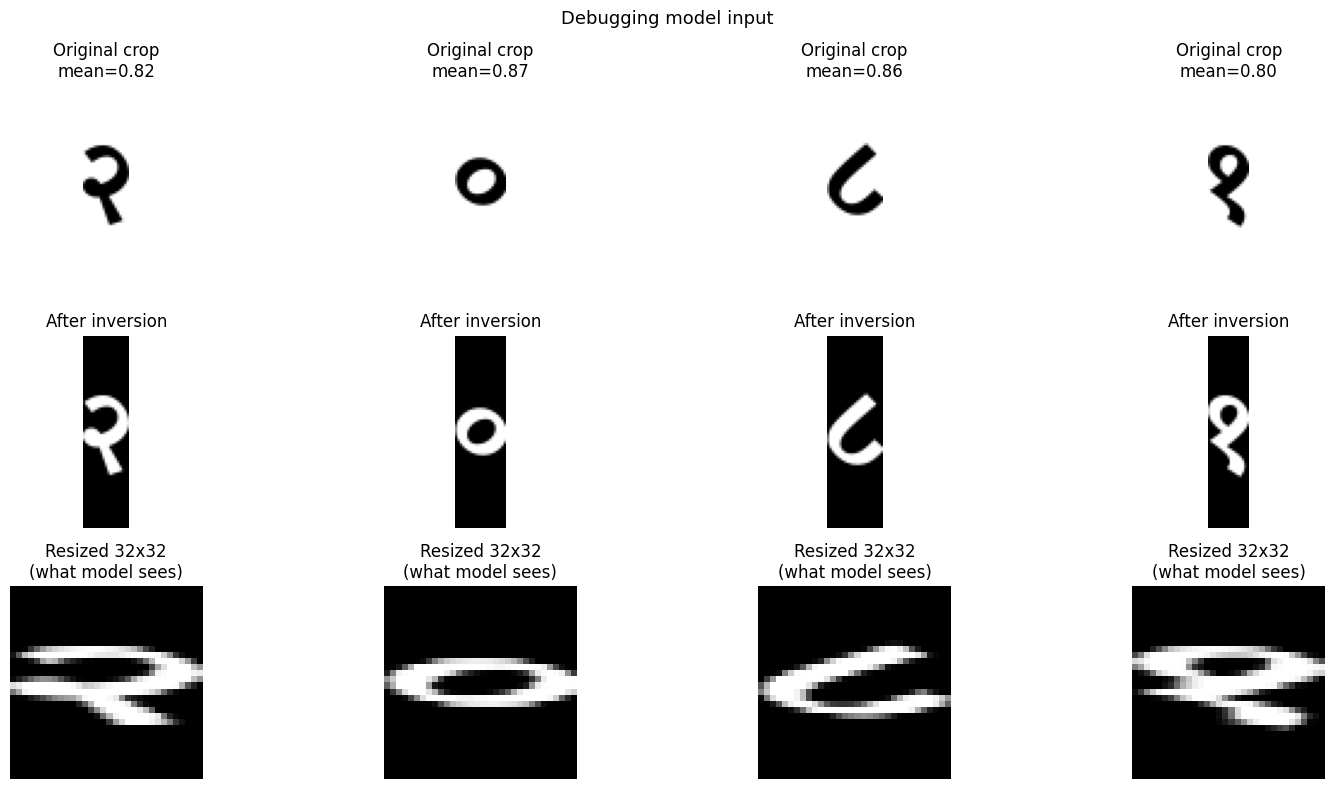

In [12]:
# ── Check exactly what model sees for each digit ────────────
fig, axes = plt.subplots(3, len(segs_d), figsize=(4 * len(segs_d), 8))

for i, (start, end) in enumerate(segs_d):
    crop    = img_gray_d[:, start:end]
    crop_np = crop.astype(np.float32) / 255.0
    
    # What model sees after inversion
    if crop_np.mean() > 0.5:
        inverted = 1.0 - crop_np
    else:
        inverted = crop_np
    
    # Resized to 32x32
    resized = cv2.resize(crop, (32, 32))
    resized_np = resized.astype(np.float32) / 255.0
    if resized_np.mean() > 0.5:
        resized_np = 1.0 - resized_np

    axes[0][i].imshow(crop, cmap='gray')
    axes[0][i].set_title(f"Original crop\nmean={crop_np.mean():.2f}")
    axes[0][i].axis('off')

    axes[1][i].imshow(inverted, cmap='gray')
    axes[1][i].set_title("After inversion")
    axes[1][i].axis('off')

    axes[2][i].imshow(resized_np, cmap='gray')
    axes[2][i].set_title("Resized 32x32\n(what model sees)")
    axes[2][i].axis('off')

plt.suptitle("Debugging model input", fontsize=13)
plt.tight_layout()
plt.show()

Verifying on known dataset digits:


/tmp/ipykernel_7809/4256161367.py:49: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/4256161367.py:49: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/4256161367.py:49: UserWarning: Glyph 84 (T) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/4256161367.py:49: UserWarning: Glyph 114 (r) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/4256161367.py:49: UserWarning: Glyph 117 (u) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/4256161367.py:49: UserWarning: Glyph 101 (e) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/4256161367.py:49: UserWarning: Glyph 80 (P) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/4256161367.py:49: UserWarning: Glyph 100 (d) missing from font(s) Noto S

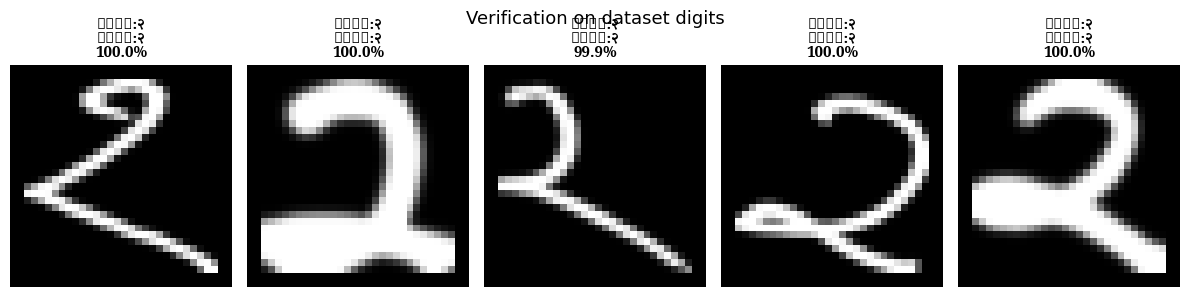

In [13]:
# ── Fixed predict_segment function ──────────────────────────
def predict_segment_v2(img_gray_crop):
    # Resize to 32x32
    resized = cv2.resize(img_gray_crop, (32, 32))
    img_np  = resized.astype(np.float32) / 255.0
    
    # Invert — make background black, digit white
    if img_np.mean() > 0.5:
        img_np = 1.0 - img_np
    
    # Check if there is actual content
    if img_np.max() < 0.1:
        return "?", 0.0
    
    # Normalize to match training data distribution
    img_np = img_np / img_np.max()  # scale to 0-1 properly
    
    tensor = torch.tensor(img_np).unsqueeze(0).unsqueeze(0)
    tensor = (tensor - 0.5) / 0.5

    with torch.no_grad():
        out   = model(tensor)
        probs = out.softmax(1)[0]
        pred  = probs.argmax().item()
        conf  = probs[pred].item()

    return CLASS_NAMES[pred], conf

# Test on dataset digits directly to verify function works
print("Verifying on known dataset digits:")
data   = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')
X_test = data['arr_2']
y_test = data['arr_3'] - 1

# Pick 5 digit samples (classes 36-45 are digits)
digit_indices = np.where(y_test >= 36)[0][:5]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, idx in enumerate(digit_indices):
    img    = X_test[idx]
    true   = CLASS_NAMES[y_test[idx]]
    char, conf = predict_segment_v2(img)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True:{true}\nPred:{char}\n{conf*100:.1f}%",
                      fontproperties=prop, fontsize=11)
    axes[i].axis('off')

plt.suptitle("Verification on dataset digits", fontsize=13)
plt.tight_layout()
plt.show()

Results with tight crop:
────────────────────────────────────────
Digit 1: → २ (99.9%)
Digit 2: → ० (99.7%)
Digit 3: → ८ (91.2%)
Digit 4: → २ (83.2%)


/tmp/ipykernel_7809/3173457000.py:60: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/3173457000.py:60: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/3173457000.py:60: UserWarning: Glyph 2408 (\N{DEVANAGARI DIGIT TWO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/3173457000.py:60: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_7809/3173457000.py:60: UserWarning: Glyph 2406 (\N{DEVANAGARI DIGIT ZERO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/3173457000.py:60: UserWarning: Glyph 2414 (\N{DEVANAGARI DIGIT EIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


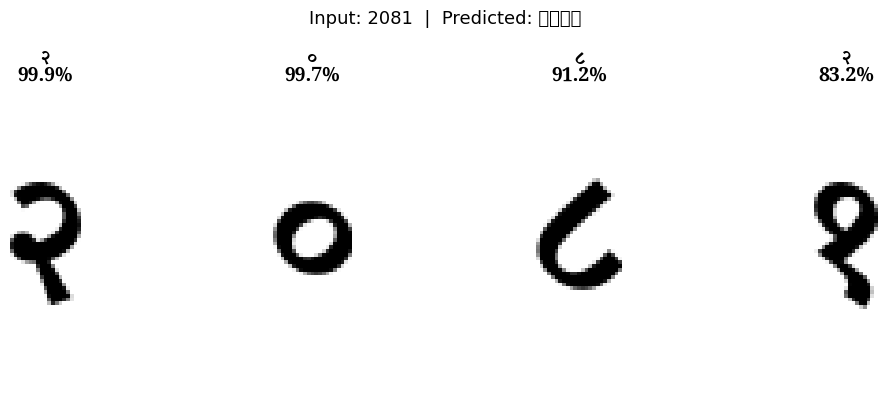


Final prediction: २०८२
Not matching


In [14]:
# ── Tight crop — remove white padding before predicting ─────
def tight_crop_and_predict(img_gray_crop):
    # Binary threshold
    _, binary = cv2.threshold(img_gray_crop, 128, 255, cv2.THRESH_BINARY_INV)
    
    # Find bounding box of actual content
    rows = np.any(binary > 0, axis=1)
    cols = np.any(binary > 0, axis=0)
    
    if not rows.any() or not cols.any():
        return "?", 0.0
    
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    
    # Tight crop
    tight = img_gray_crop[rmin:rmax+1, cmin:cmax+1]
    
    # Add small padding
    pad    = 4
    padded = np.full((tight.shape[0] + 2*pad, tight.shape[1] + 2*pad), 255, dtype=np.uint8)
    padded[pad:pad+tight.shape[0], pad:pad+tight.shape[1]] = tight
    
    # Resize to 32x32
    resized = cv2.resize(padded, (32, 32))
    img_np  = resized.astype(np.float32) / 255.0
    
    # Invert
    if img_np.mean() > 0.5:
        img_np = 1.0 - img_np
    
    tensor = torch.tensor(img_np).unsqueeze(0).unsqueeze(0)
    tensor = (tensor - 0.5) / 0.5

    with torch.no_grad():
        out   = model(tensor)
        probs = out.softmax(1)[0]
        pred  = probs.argmax().item()
        conf  = probs[pred].item()

    return CLASS_NAMES[pred], conf

# Now predict digits with tight crop
print("Results with tight crop:")
print("─" * 40)
fig, axes = plt.subplots(1, len(segs_d), figsize=(3 * len(segs_d), 4))
predicted = ""

for i, (start, end) in enumerate(segs_d):
    crop       = img_gray_d[:, start:end]
    char, conf = tight_crop_and_predict(crop)
    predicted += char
    print(f"Digit {i+1}: → {char} ({conf*100:.1f}%)")
    axes[i].imshow(crop, cmap='gray')
    axes[i].set_title(char + "\n" + str(round(conf*100,1)) + "%",
                      fontproperties=prop, fontsize=14)
    axes[i].axis('off')

plt.suptitle("Input: 2081  |  Predicted: " + predicted, fontsize=13)
plt.tight_layout()
plt.show()
print("\nFinal prediction:", predicted)
print("Correct!" if predicted == digit_text else "Not matching")

Last segment: columns 87 to 104, width=17


/tmp/ipykernel_7809/2920137088.py:25: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/2920137088.py:25: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/2920137088.py:25: UserWarning: Glyph 79 (O) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/2920137088.py:25: UserWarning: Glyph 114 (r) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/2920137088.py:25: UserWarning: Glyph 105 (i) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/2920137088.py:25: UserWarning: Glyph 103 (g) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/2920137088.py:25: UserWarning: Glyph 110 (n) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/2920137088.py:25: UserWarning: Glyph 97 (a) missing from font(s) Noto S

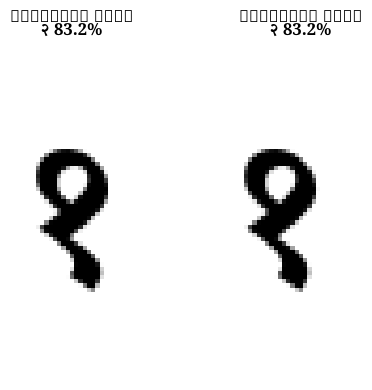

Original:  २ (83.2%)
Extended:  २ (83.2%)


In [15]:
# ── Check last digit crop closely ───────────────────────────
start, end = segs_d[3]  # last segment
print(f"Last segment: columns {start} to {end}, width={end-start}")

crop = img_gray_d[:, start:end]

# Extend the crop slightly to the right to capture full digit
end_extended = min(end + 10, img_gray_d.shape[1])
crop_extended = img_gray_d[:, start:end_extended]

char1, conf1 = tight_crop_and_predict(crop)
char2, conf2 = tight_crop_and_predict(crop_extended)

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(crop, cmap='gray')
axes[0].set_title(f"Original crop\n{char1} {conf1*100:.1f}%",
                  fontproperties=prop, fontsize=12)
axes[0].axis('off')

axes[1].imshow(crop_extended, cmap='gray')
axes[1].set_title(f"Extended crop\n{char2} {conf2*100:.1f}%",
                  fontproperties=prop, fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()
print(f"Original:  {char1} ({conf1*100:.1f}%)")
print(f"Extended:  {char2} ({conf2*100:.1f}%)")

/tmp/ipykernel_7809/2984823012.py:35: UserWarning: Glyph 2407 (\N{DEVANAGARI DIGIT ONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/2984823012.py:35: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()


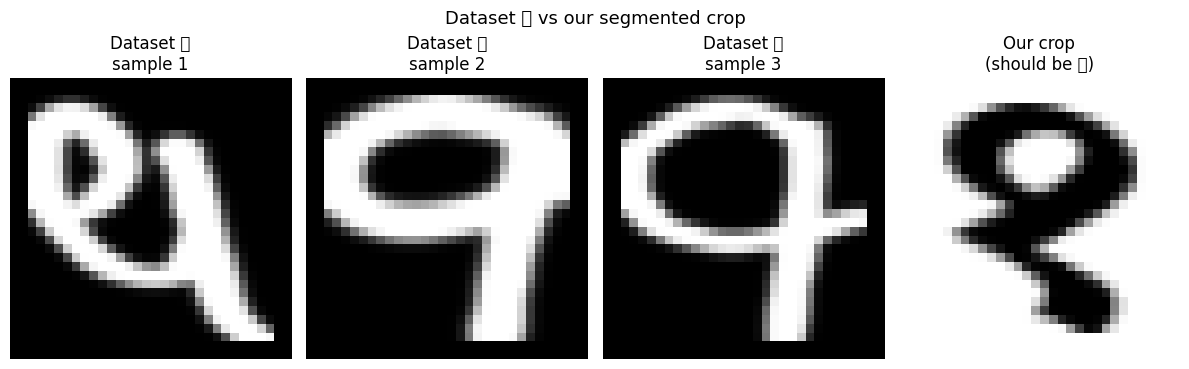

In [16]:
# ── Compare dataset १ vs our crop ───────────────────────────
data   = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')
X_test = data['arr_2']
y_test = data['arr_3'] - 1

# Find some १ samples from dataset (class index 37)
one_indices = np.where(y_test == 37)[0][:3]

# Get our last digit crop processed
crop_last = img_gray_d[:, 87:114]
_, binary_last = cv2.threshold(crop_last, 128, 255, cv2.THRESH_BINARY_INV)
rows = np.any(binary_last > 0, axis=1)
cols = np.any(binary_last > 0, axis=0)
rmin, rmax = np.where(rows)[0][[0, -1]]
cmin, cmax = np.where(cols)[0][[0, -1]]
tight_last = crop_last[rmin:rmax+1, cmin:cmax+1]
padded_last = np.full((tight_last.shape[0]+8, tight_last.shape[1]+8), 255, dtype=np.uint8)
padded_last[4:4+tight_last.shape[0], 4:4+tight_last.shape[1]] = tight_last
resized_last = cv2.resize(padded_last, (32, 32))

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

# Show dataset १ samples
for i, idx in enumerate(one_indices):
    axes[i].imshow(X_test[idx], cmap='gray')
    axes[i].set_title(f"Dataset १\nsample {i+1}")
    axes[i].axis('off')

# Show our crop
axes[3].imshow(resized_last, cmap='gray')
axes[3].set_title("Our crop\n(should be १)")
axes[3].axis('off')

plt.suptitle("Dataset १ vs our segmented crop", fontsize=13)
plt.tight_layout()
plt.show()

Generated 1/46 classes...
Generated 11/46 classes...
Generated 21/46 classes...
Generated 31/46 classes...
Generated 41/46 classes...

Synthetic data shape: (23000, 32, 32)
Labels shape: (23000,)
Saved to data/synthetic_font_data.npz


/tmp/ipykernel_7809/1744863148.py:78: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/1744863148.py:78: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()


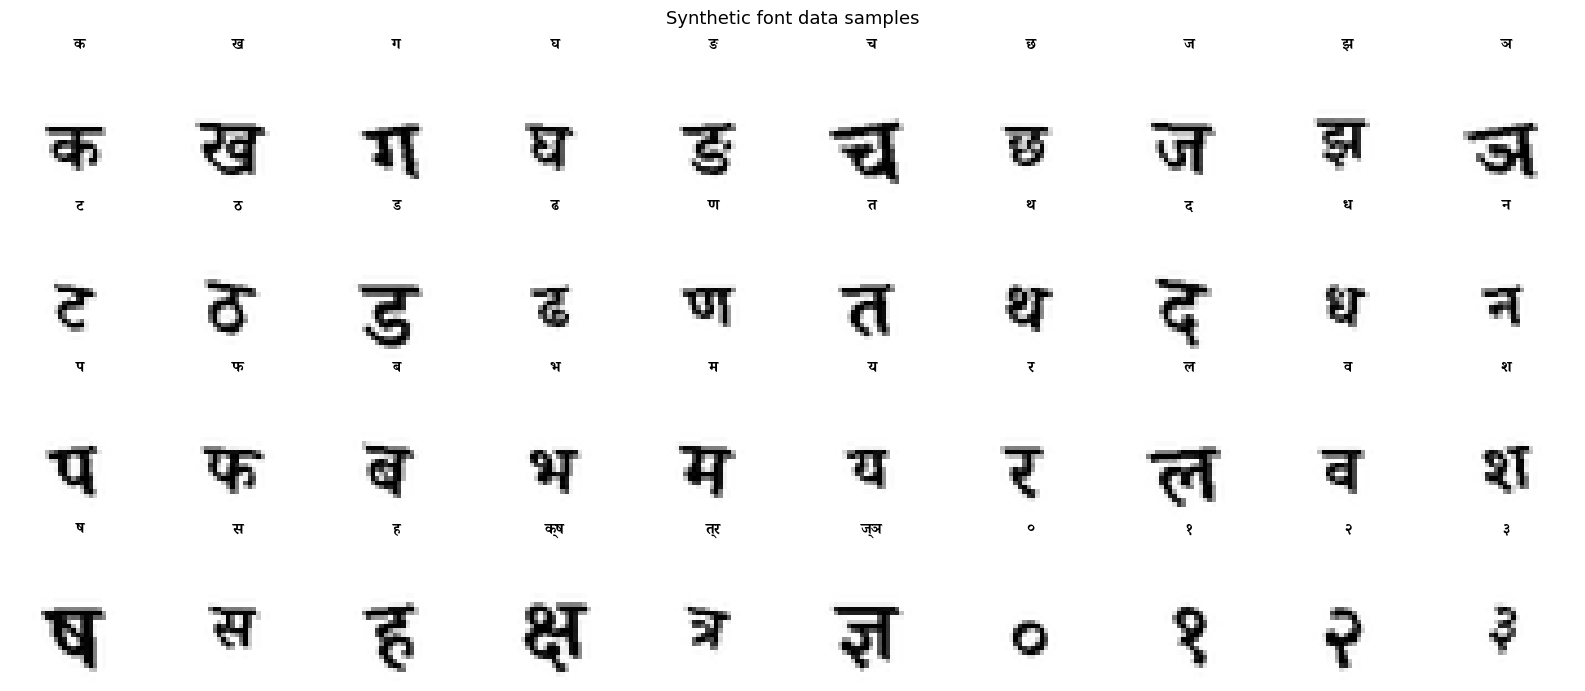

In [17]:
# ── Generate synthetic typed font data ──────────────────────
import os
from PIL import Image, ImageDraw, ImageFont

FONT_PATH = '/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf'
OUT_DIR   = '/home/kulraj/nepali_ocr/data/synthetic'
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_NAMES = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
               'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
               'प','फ','ब','भ','म','य','र','ल','व','श',
               'ष','स','ह','क्ष','त्र','ज्ञ',
               '०','१','२','३','४','५','६','७','८','९']

import random

def render_char(char, font_path, size, img_size=32, noise=True):
    font  = ImageFont.truetype(font_path, size=size)
    img   = Image.new('L', (img_size*2, img_size*2), color=255)
    draw  = ImageDraw.Draw(img)
    
    # Center the character
    bbox = draw.textbbox((0,0), char, font=font)
    w    = bbox[2] - bbox[0]
    h    = bbox[3] - bbox[1]
    x    = (img_size*2 - w) // 2
    y    = (img_size*2 - h) // 2
    draw.text((x, y), char, font=font, fill=0)
    
    # Random augmentation
    if noise:
        # Random rotation
        angle = random.uniform(-10, 10)
        img   = img.rotate(angle, fillcolor=255)
        
        # Random scale — vary font size
        pass
    
    # Resize to 32x32
    img = img.resize((img_size, img_size), Image.LANCZOS)
    return np.array(img)

# Generate 500 images per class
N_PER_CLASS = 500
font_sizes  = [28, 32, 36, 40, 44]  # vary font size for robustness

all_images = []
all_labels = []

for class_idx, char in enumerate(CLASS_NAMES):
    for i in range(N_PER_CLASS):
        size    = random.choice(font_sizes)
        img_arr = render_char(char, FONT_PATH, size, noise=True)
        all_images.append(img_arr)
        all_labels.append(class_idx)
    
    if class_idx % 10 == 0:
        print(f"Generated {class_idx+1}/{len(CLASS_NAMES)} classes...")

all_images = np.array(all_images, dtype=np.uint8)
all_labels = np.array(all_labels, dtype=np.int64)

print(f"\nSynthetic data shape: {all_images.shape}")
print(f"Labels shape: {all_labels.shape}")

# Save
np.savez('/home/kulraj/nepali_ocr/data/synthetic_font_data.npz',
         images=all_images, labels=all_labels)
print("Saved to data/synthetic_font_data.npz")

# Preview
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(all_images[i * 500], cmap='gray')
    ax.set_title(CLASS_NAMES[all_labels[i * 500]], fontproperties=prop, fontsize=11)
    ax.axis('off')
plt.suptitle('Synthetic font data samples', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import cv2

prop = fm.FontProperties(
    fname='/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf')

class DHCDDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images  = images.astype(np.float32) / 255.0
        self.labels  = labels.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx]).unsqueeze(0)
        if self.augment:
            img = T.RandomRotation(10)(img)
            img = T.RandomAffine(degrees=0, translate=(0.1, 0.1))(img)
        img = T.Normalize((0.5,), (0.5,))(img)
        return img, self.labels[idx]

class NepaliOCR_CNN(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

device = torch.device('cpu')
torch.set_num_threads(6)
print("All classes defined!")
print("Device:", device)

All classes defined!
Device: cpu


In [19]:
# ── Combine DHCD + Synthetic data and retrain ───────────────

# Load original DHCD data
dhcd = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')
X_train_dhcd = dhcd['arr_0']
y_train_dhcd = dhcd['arr_1'] - 1
X_test_dhcd  = dhcd['arr_2']
y_test_dhcd  = dhcd['arr_3'] - 1

# Load synthetic data
synth    = np.load('/home/kulraj/nepali_ocr/data/synthetic_font_data.npz')
X_synth  = synth['images']
y_synth  = synth['labels']

# Split synthetic into train/test (80/20)
split        = int(0.8 * len(X_synth))
X_synth_train = X_synth[:split]
y_synth_train = y_synth[:split]
X_synth_test  = X_synth[split:]
y_synth_test  = y_synth[split:]

# Combine
X_train_combined = np.concatenate([X_train_dhcd, X_synth_train], axis=0)
y_train_combined = np.concatenate([y_train_dhcd, y_synth_train], axis=0)
X_test_combined  = np.concatenate([X_test_dhcd,  X_synth_test],  axis=0)
y_test_combined  = np.concatenate([y_test_dhcd,  y_synth_test],  axis=0)

print(f"DHCD train:      {X_train_dhcd.shape}")
print(f"Synthetic train: {X_synth_train.shape}")
print(f"Combined train:  {X_train_combined.shape}")
print(f"Combined test:   {X_test_combined.shape}")

# Dataset and DataLoader
train_ds2 = DHCDDataset(X_train_combined, y_train_combined, augment=True)
test_ds2  = DHCDDataset(X_test_combined,  y_test_combined,  augment=False)

train_loader2 = DataLoader(train_ds2, batch_size=64, shuffle=True,  num_workers=0)
test_loader2  = DataLoader(test_ds2,  batch_size=64, shuffle=False, num_workers=0)

print(f"\nTrain batches: {len(train_loader2)}")
print(f"Test batches:  {len(test_loader2)}")

DHCD train:      (78200, 32, 32)
Synthetic train: (18400, 32, 32)
Combined train:  (96600, 32, 32)
Combined test:   (18400, 32, 32)

Train batches: 1510
Test batches:  288


In [20]:
# ── Retrain on combined DHCD + Synthetic data ────────────────
model2    = NepaliOCR_CNN(num_classes=46).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

EPOCHS = 20  # less epochs since more data

for epoch in range(EPOCHS):
    model2.train()
    total_loss = 0
    correct    = 0

    for imgs, labels in train_loader2:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model2(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_ds2) * 100

    model2.eval()
    val_correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader2:
            imgs, labels = imgs.to(device), labels.to(device)
            val_correct += (model2(imgs).argmax(1) == labels).sum().item()

    val_acc = val_correct / len(test_ds2) * 100
    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss/len(train_loader2):.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

print("\nDone! Saving...")
torch.save(model2.state_dict(), '/home/kulraj/nepali_ocr/models/nepali_ocr_combined.pth')
print("Saved to models/nepali_ocr_combined.pth")

Epoch 01/20 | Loss: 1.9685 | Train: 41.68% | Val: 67.46%
Epoch 02/20 | Loss: 1.0825 | Train: 64.90% | Val: 71.02%
Epoch 03/20 | Loss: 0.8452 | Train: 72.47% | Val: 73.77%
Epoch 04/20 | Loss: 0.7078 | Train: 77.04% | Val: 73.76%
Epoch 05/20 | Loss: 0.5882 | Train: 81.01% | Val: 74.19%
Epoch 06/20 | Loss: 0.5058 | Train: 83.79% | Val: 73.76%
Epoch 07/20 | Loss: 0.4341 | Train: 86.28% | Val: 74.16%
Epoch 08/20 | Loss: 0.3850 | Train: 87.98% | Val: 74.65%
Epoch 09/20 | Loss: 0.3378 | Train: 89.63% | Val: 74.03%
Epoch 10/20 | Loss: 0.3028 | Train: 90.84% | Val: 74.17%
Epoch 11/20 | Loss: 0.2482 | Train: 92.47% | Val: 74.36%
Epoch 12/20 | Loss: 0.2201 | Train: 93.37% | Val: 74.51%
Epoch 13/20 | Loss: 0.2109 | Train: 93.64% | Val: 74.60%
Epoch 14/20 | Loss: 0.1960 | Train: 94.11% | Val: 74.51%
Epoch 15/20 | Loss: 0.1859 | Train: 94.50% | Val: 74.67%
Epoch 16/20 | Loss: 0.1740 | Train: 94.83% | Val: 74.61%
Epoch 17/20 | Loss: 0.1700 | Train: 94.97% | Val: 74.57%
Epoch 18/20 | Loss: 0.1616 | Tr

Combined model loaded!
Segments: [(12, 31), (35, 56), (61, 84), (87, 104)]

Results:
────────────────────────────────────────
Digit 1: → २ (99.9%)
Digit 2: → ० (99.7%)
Digit 3: → ७ (65.5%)
Digit 4: → ९ (83.4%)


/tmp/ipykernel_7809/1992392149.py:67: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/1992392149.py:67: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_7809/1992392149.py:67: UserWarning: Glyph 2408 (\N{DEVANAGARI DIGIT TWO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/1992392149.py:67: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_7809/1992392149.py:67: UserWarning: Glyph 2406 (\N{DEVANAGARI DIGIT ZERO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/1992392149.py:67: UserWarning: Glyph 2413 (\N{DEVANAGARI DIGIT SEVEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7809/1992392149.py:67: UserWarning: Glyph 2415 (\N{DEVANAGARI DIGIT NINE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


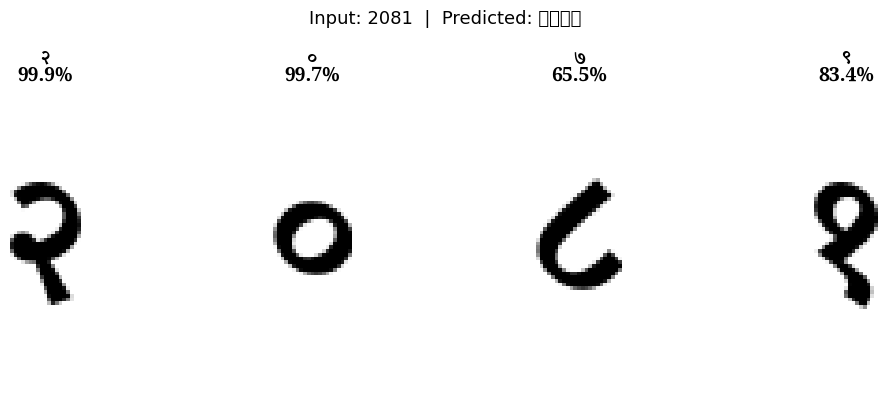


Final prediction: २०७९
Not matching


In [22]:
# ── Test combined model on typed digits ──────────────────────
model2 = NepaliOCR_CNN(num_classes=46)
model2.load_state_dict(torch.load('/home/kulraj/nepali_ocr/models/nepali_ocr_combined.pth',
                                   map_location=device))
model2.eval()
print("Combined model loaded!")

CLASS_NAMES = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
               'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
               'प','फ','ब','भ','म','य','र','ल','व','श',
               'ष','स','ह','क्ष','त्र','ज्ञ',
               '०','१','२','३','४','५','६','७','८','९']

def tight_crop_and_predict_v2(img_gray_crop):
    _, binary = cv2.threshold(img_gray_crop, 128, 255, cv2.THRESH_BINARY_INV)
    rows = np.any(binary > 0, axis=1)
    cols = np.any(binary > 0, axis=0)
    if not rows.any() or not cols.any():
        return "?", 0.0
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    tight  = img_gray_crop[rmin:rmax+1, cmin:cmax+1]
    pad    = 4
    padded = np.full((tight.shape[0]+2*pad, tight.shape[1]+2*pad), 255, dtype=np.uint8)
    padded[pad:pad+tight.shape[0], pad:pad+tight.shape[1]] = tight
    resized = cv2.resize(padded, (32, 32))
    img_np  = resized.astype(np.float32) / 255.0
    if img_np.mean() > 0.5:
        img_np = 1.0 - img_np
    tensor = torch.tensor(img_np).unsqueeze(0).unsqueeze(0)
    tensor = (tensor - 0.5) / 0.5
    with torch.no_grad():
        out   = model2(tensor)
        probs = out.softmax(1)[0]
        pred  = probs.argmax().item()
        conf  = probs[pred].item()
    return CLASS_NAMES[pred], conf

# Create digit image
from PIL import Image, ImageDraw, ImageFont
digit_text = '२०८१'
font       = ImageFont.truetype('/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf', 48)
digit_img  = Image.new('RGB', (400, 80), color=(255, 255, 255))
draw       = ImageDraw.Draw(digit_img)
draw.text((10, 10), digit_text, font=font, fill=(0, 0, 0))
digit_gray = np.array(digit_img.convert('L'))

# Segment and predict
_, _, _, segs_d = segment_digits(digit_img)
print(f"Segments: {segs_d}")
print("\nResults:")
print("─" * 40)
fig, axes = plt.subplots(1, len(segs_d), figsize=(3*len(segs_d), 4))
predicted = ""

for i, (start, end) in enumerate(segs_d):
    crop       = digit_gray[:, start:end]
    char, conf = tight_crop_and_predict_v2(crop)
    predicted += char
    print(f"Digit {i+1}: → {char} ({conf*100:.1f}%)")
    axes[i].imshow(crop, cmap='gray')
    axes[i].set_title(char + "\n" + str(round(conf*100,1)) + "%",
                      fontproperties=prop, fontsize=14)
    axes[i].axis('off')

plt.suptitle("Input: 2081  |  Predicted: " + predicted, fontsize=13)
plt.tight_layout()
plt.show()
print("\nFinal prediction:", predicted)
print("Correct!" if predicted == digit_text else "Not matching")